# 🫀 Baseline Model - Heart Disease Classification

- **Author**: Laura Granda
- **Date**: 2026-03-15
- **Input**: `data/03_primary/corazon_explored.parquet`
- **Output**: Cross-validation metrics + learning curve

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, get_scorer
from sklearn.model_selection import (
    KFold,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline

# Add project root to python path
sys.path.append(str(Path.cwd().resolve().parents[1]))
from src.pipelines.feature_pipeline.build_features import create_preprocessor

## 💾 Load data

In [ ]:
DATA_PATH: Path = (
    Path.cwd().resolve().parents[1] / "data" / "03_primary" / "corazon_explored.parquet"
)
FEATURES: list[str] = [
    "age",
    "max_hr",
    "old_peak",
    "chest_pain",
    "sex",
    "thal",
    "slope",
    "ca",
    "exang",
]
TARGET: str = "disease"
CATEGORICAL_ORDINAL: list[str] = ["chest_pain", "sex", "thal", "slope", "ca", "exang"]

df: pd.DataFrame = pd.read_parquet(DATA_PATH)
print(f"Shape before drop_duplicates: {df.shape}")
df = df.drop_duplicates()
print(f"Shape after drop_duplicates: {df.shape}")

# Select only preprocessor features + target
df = df[[*FEATURES, TARGET]]

# Convert categorical/ordinal columns to object dtype for sklearn compatibility
for col in CATEGORICAL_ORDINAL:
    df[col] = df[col].astype(str)

## ✂️ Train / Test split

In [3]:
X: pd.DataFrame = df[FEATURES]
y: pd.Series = df[TARGET]

X_train: pd.DataFrame
X_test: pd.DataFrame
y_train: pd.Series
y_test: pd.Series

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

X_train: (384, 9) | X_test: (96, 9)
y_train: (384,) | y_test: (96,)


## 🤖 Baseline Model

In [ ]:
model: LogisticRegression = LogisticRegression(random_state=42, max_iter=1000)
preprocessor = create_preprocessor()

pipeline: Pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

## 📊 Predict and Evaluation

In [ ]:
SCORING_METRICS: list[str] = ["accuracy", "f1", "precision", "recall"]
N_SPLITS: int = 10

kfold: KFold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

cv_results: dict[str, list[float]] = {}
train_scores_dict: dict[str, float] = {}

for metric in SCORING_METRICS:
    # Create fresh pipeline for each metric to avoid state issues
    metric_pipeline: Pipeline = Pipeline(
        steps=[
            ("preprocessor", create_preprocessor()),
            ("model", LogisticRegression(random_state=42, max_iter=1000)),
        ]
    )

    # Cross-validation scores
    cv_scores: np.ndarray = cross_val_score(
        metric_pipeline, X_train, y_train, cv=kfold, scoring=metric
    )

    # Train score: fit on full training data and score
    metric_pipeline.fit(X_train, y_train)
    scorer = get_scorer(metric)
    train_score: float = scorer(metric_pipeline, X_train, y_train)

    cv_results[metric] = cv_scores.tolist()
    train_scores_dict[metric] = train_score

    print(
        f"{metric.upper():10s} | CV Mean: {cv_scores.mean():.4f} | CV Std: {cv_scores.std():.4f} | Train: {train_score:.4f}"
    )

# Create final pipeline for learning curve
pipeline = Pipeline(
    steps=[
        ("preprocessor", create_preprocessor()),
        ("model", LogisticRegression(random_state=42, max_iter=1000)),
    ]
)

ACCURACY   | CV Mean: 0.8076 | CV Std: 0.0618 | Train: 0.8203
F1         | CV Mean: 0.7904 | CV Std: 0.0760 | Train: 0.8078
PRECISION  | CV Mean: 0.8201 | CV Std: 0.1192 | Train: 0.8286
RECALL     | CV Mean: 0.7784 | CV Std: 0.1139 | Train: 0.7880


/tmp/ipykernel_236381/1101861212.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(cv_results.values(), labels=[m.capitalize() for m in SCORING_METRICS])


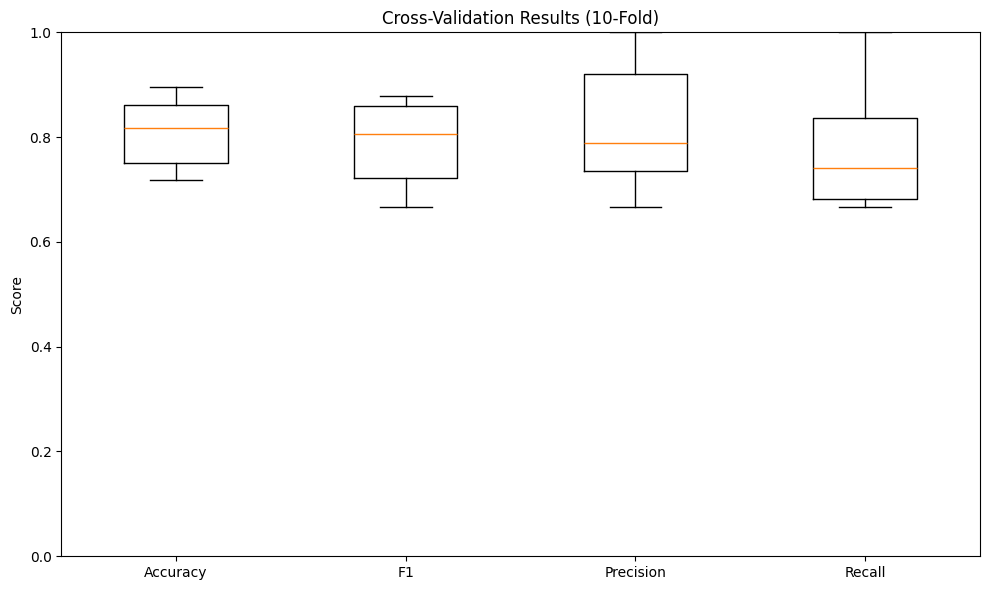

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(cv_results.values(), labels=[m.capitalize() for m in SCORING_METRICS])
ax.set_title("Cross-Validation Results (10-Fold)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

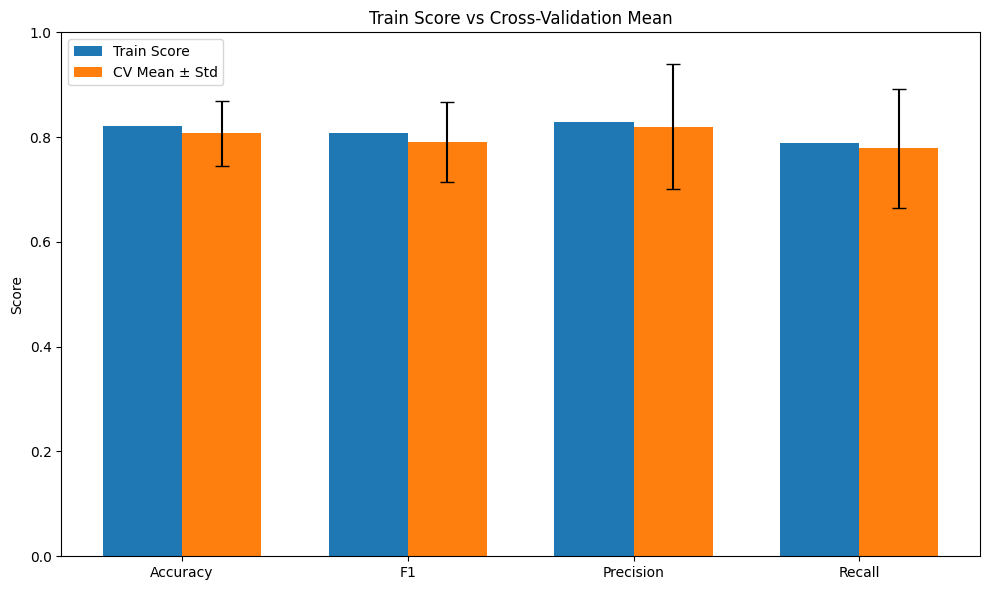

In [ ]:
metrics: list[str] = list(cv_results.keys())
cv_means: list[float] = [np.mean(cv_results[m]) for m in metrics]
cv_stds: list[float] = [np.std(cv_results[m]) for m in metrics]
train_scores: list[float] = [train_scores_dict[m] for m in metrics]

x: np.ndarray = np.arange(len(metrics))
width: float = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width / 2, train_scores, width, label="Train Score")
ax.bar(x + width / 2, cv_means, width, yerr=cv_stds, capsize=5, label="CV Mean ± Std")
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylim(0, 1)
ax.set_title("Train Score vs Cross-Validation Mean")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

## 📈 Learning Curve (Recall)

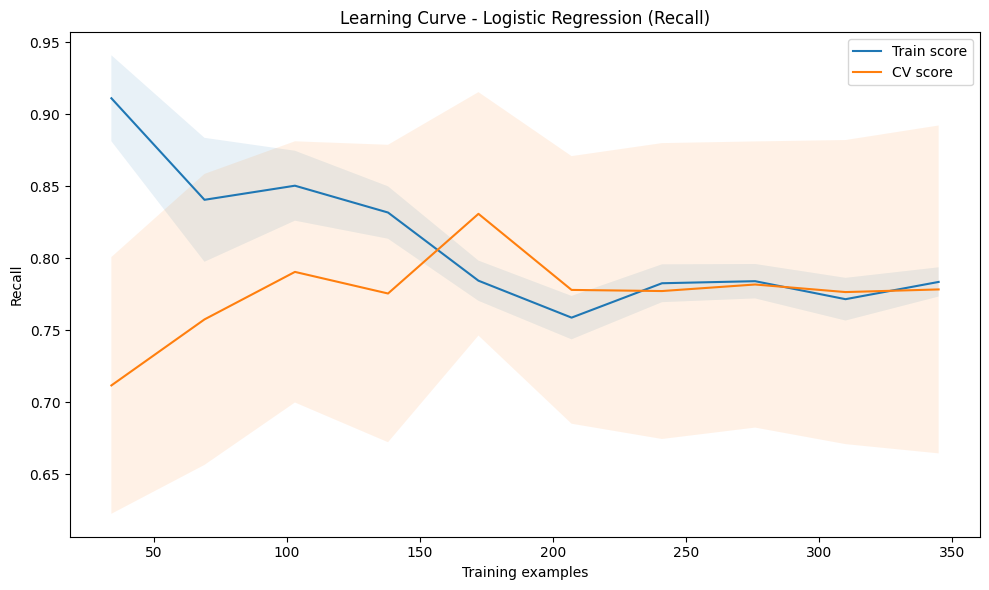

In [ ]:
train_sizes: np.ndarray
train_scores_lc: np.ndarray
cv_scores_lc: np.ndarray

train_sizes, train_scores_lc, cv_scores_lc = learning_curve(
    pipeline,
    X_train,
    y_train,
    cv=kfold,
    scoring="recall",
    train_sizes=np.linspace(0.1, 1.0, 10),
)

train_mean: np.ndarray = train_scores_lc.mean(axis=1)
train_std: np.ndarray = train_scores_lc.std(axis=1)
cv_mean: np.ndarray = cv_scores_lc.mean(axis=1)
cv_std: np.ndarray = cv_scores_lc.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, label="Train score")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
ax.plot(train_sizes, cv_mean, label="CV score")
ax.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.1)
ax.set_xlabel("Training examples")
ax.set_ylabel("Recall")
ax.set_title("Learning Curve - Logistic Regression (Recall)")
ax.legend()
plt.tight_layout()
plt.show()

## 🧪 Test Set Evaluation

In [9]:
# Fit final pipeline on entire training set
pipeline.fit(X_train, y_train)

# Predictions on test set
y_pred: np.ndarray = pipeline.predict(X_test)
y_pred_proba: np.ndarray = pipeline.predict_proba(X_test)

# Test set metrics
test_accuracy: float = pipeline.score(X_test, y_test)
print(f"Test Set Accuracy: {test_accuracy:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))

Test Set Accuracy: 0.8125

Classification Report (Test Set):
              precision    recall  f1-score   support

  No Disease       0.86      0.76      0.81        50
     Disease       0.77      0.87      0.82        46

    accuracy                           0.81        96
   macro avg       0.82      0.81      0.81        96
weighted avg       0.82      0.81      0.81        96



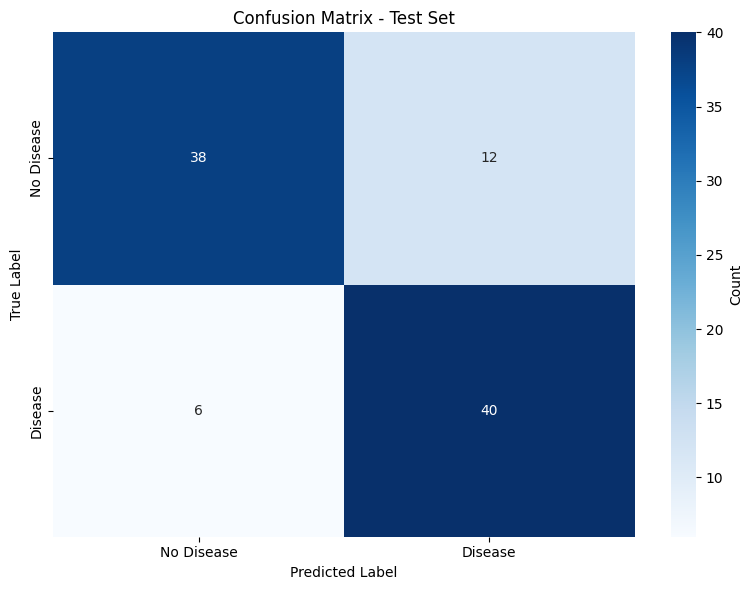


Confusion Matrix Breakdown:
True Negatives (TN):  38
False Positives (FP): 12
False Negatives (FN): 6
True Positives (TP):  40


In [ ]:
# Confusion Matrix
cm: np.ndarray = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"],
    cbar_kws={"label": "Count"},
    ax=ax,
)
ax.set_title("Confusion Matrix - Test Set")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Print confusion matrix details
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Breakdown:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")